In [12]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

# 패션 MNIST 데이터 로드 및 전처리
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)


# 모델 생성 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))  # 입력
    model.add(keras.layers.Flatten())  # 평탄화 784
    model.add(keras.layers.Dense(100, activation='relu'))  # 은닉층
    if a_layer:
        model.add(a_layer)         # 매개변수가 있는 경우에만 선택적으로 삽입하는 layer
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
    return model

In [13]:
model = model_fn()
model.compile(
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=[keras.metrics.sparse_categorical_accuracy]
)
# model.compile(loss='sparse_catergorical_crosentropy', metrics=['accuracy']) # 문자열 입력
history = model.fit(train_scaled, train_target, epochs=5)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5311 - sparse_categorical_accuracy: 0.8112
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3906 - sparse_categorical_accuracy: 0.8586
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3533 - sparse_categorical_accuracy: 0.8728
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3294 - sparse_categorical_accuracy: 0.8809
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3129 - sparse_categorical_accuracy: 0.8888


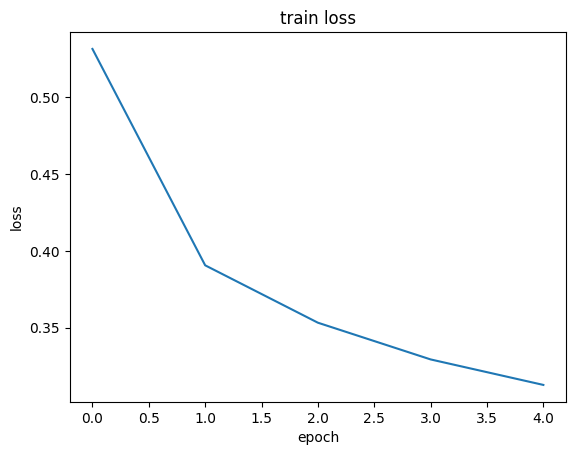

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')
plt.show()


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5374 - sparse_categorical_accuracy: 0.8109 - val_loss: 0.4314 - val_sparse_categorical_accuracy: 0.8472
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3976 - sparse_categorical_accuracy: 0.8555 - val_loss: 0.3865 - val_sparse_categorical_accuracy: 0.8613
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3574 - sparse_categorical_accuracy: 0.8714 - val_loss: 0.3868 - val_sparse_categorical_accuracy: 0.8614
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3327 - sparse_categorical_accuracy: 0.8810 - val_loss: 0.3803 - val_sparse_categorical_accuracy: 0.8660
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3161 - sparse_categorical_accuracy: 0.8873 - val_loss: 0.3845 - val_sparse_categorical_accuracy: 0.8664
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3015 - sparse_categorical_accuracy: 0.8926 - val_loss: 0.3798 - val_sparse_categorical_accuracy:

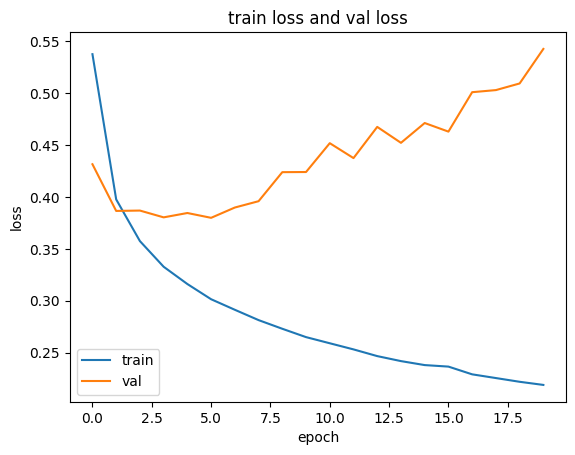

In [15]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, # 에폭 20, 출력 없이
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

In [16]:
model = model_fn(a_layer=keras.layers.Dropout(0.3))  # 드롭 아웃
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

KeyboardInterrupt: 